In [1]:
# 1. Importing Necessary Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load the dataset from the CSV file
file_path = 'C:\DISCAPACIDADES.csv'  # Make sure the file path is correct
df = pd.read_csv(file_path)

# 3. Remove the 'ID' column
df_cleaned = df.drop(columns=['ID'])

# 4. Fill missing values in 'AÑO 2010' and 'AÑO 2020' with 0
df_cleaned['AÑO 2010'] = df_cleaned['AÑO 2010'].fillna(0).astype(int)
df_cleaned['AÑO 2020'] = df_cleaned['AÑO 2020'].fillna(0).astype(int)

# 5. Check for duplicates in 'NUM-MUNICIPIO'
duplicates = df_cleaned[df_cleaned.duplicated(subset=['NUM-MUNICIPIO'], keep=False)]

if not duplicates.empty:
    print("Se encontraron filas duplicadas en 'NUM-MUNICIPIO':")
    print(duplicates)
    # Here, we decide to drop duplicates. Adjust as necessary.
    df_cleaned = df_cleaned.drop_duplicates(subset=['NUM-MUNICIPIO'])
else:
    print("No se encontraron duplicados en 'NUM-MUNICIPIO'.")

# 6. Save the cleaned data to a new CSV file for future reference
df_cleaned.to_csv('DISCAPACIDADES_cleaned.csv', index=False)

# 7. Now, let's load the cleaned dataset for further analysis
file_path = 'DISCAPACIDADES_cleaned.csv'  # Again, make sure this path is correct
df_cleaned = pd.read_csv(file_path)

# 8. Filter the columns we care about
filtered_df = df_cleaned[['ENTIDAD', 'MUNICIPIO', 'INDICADOR', 'AÑO 2010', 'AÑO 2020', 'unidad_medida']]

# 9. Calculate the percentage change and add it as a new column
filtered_df['PORCENTAJE_CAMBIO'] = ((filtered_df['AÑO 2010'] - filtered_df['AÑO 2020']) / filtered_df['AÑO 2010']) * 100

# 10. Calculate totals for AÑO 2010 and AÑO 2020
total_año_2010 = filtered_df['AÑO 2010'].sum()
total_año_2020 = filtered_df['AÑO 2020'].sum()

# 11. Calculate the total percentage change based on the total values
total_porcentaje_cambio = ((total_año_2010 - total_año_2020) / total_año_2010) * 100

# 12. Prepare a dictionary for the totals row
totals = {
    'ENTIDAD': 'Total',
    'MUNICIPIO': '',
    'INDICADOR': '',
    'AÑO 2010': total_año_2010,
    'AÑO 2020': total_año_2020,
    'unidad_medida': '',
    'PORCENTAJE_CAMBIO': total_porcentaje_cambio
}

# 13. Create a DataFrame for the totals row
totals_df = pd.DataFrame([totals])

# 14. Concatenate the totals row with the original filtered DataFrame
filtered_df = pd.concat([filtered_df, totals_df], ignore_index=True)

# 15. Let's print the filtered DataFrame with totals to see what we have
print(filtered_df)

# 16. Prepare data for plotting the totals
totals_row = filtered_df[filtered_df['ENTIDAD'] == 'Total']

# 17. Extract total values for plotting
año_2010_total = totals_row['AÑO 2010'].values[0]
año_2020_total = totals_row['AÑO 2020'].values[0]

# 18. Prepare data for bar plotting
total_data = {
    'Año': ['AÑO 2010', 'AÑO 2020'],
    'Total': [año_2010_total, año_2020_total]
}
total_df = pd.DataFrame(total_data)

<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Zephyrus\AppData\Local\Temp\ipykernel_7312\4104389216.py:7: SyntaxWarning: invalid escape sequence '\D'
  file_path = 'C:\DISCAPACIDADES.csv'  # Make sure the file path is correct


No se encontraron duplicados en 'NUM-MUNICIPIO'.
    ENTIDAD         MUNICIPIO  \
0   Yucatán           Estatal   
1   Yucatán             Abalá   
2   Yucatán           Acanceh   
3   Yucatán              Akil   
4   Yucatán              Baca   
5   Yucatán            Bokobá   
6   Yucatán          Buctzotz   
7   Yucatán         Cacalchén   
8   Yucatán          Calotmul   
9   Yucatán         Cansahcab   
10  Yucatán        Cantamayec   
11  Yucatán          Celestún   
12  Yucatán         Cenotillo   
13  Yucatán            Conkal   
14  Yucatán          Cuncunul   
15  Yucatán            Cuzamá   
16  Yucatán        Chacsinkín   
17  Yucatán           Chankom   
18  Yucatán            Chapab   
19  Yucatán            Chemax   
20  Yucatán  Chicxulub Pueblo   
21  Yucatán        Chichimilá   
22  Yucatán      Chikindzonot   
23  Yucatán          Chocholá   
24  Yucatán          Chumayel   
25  Yucatán              Dzán   
26  Yucatán            Dzemul   
27  Yucatán        Dzidzant

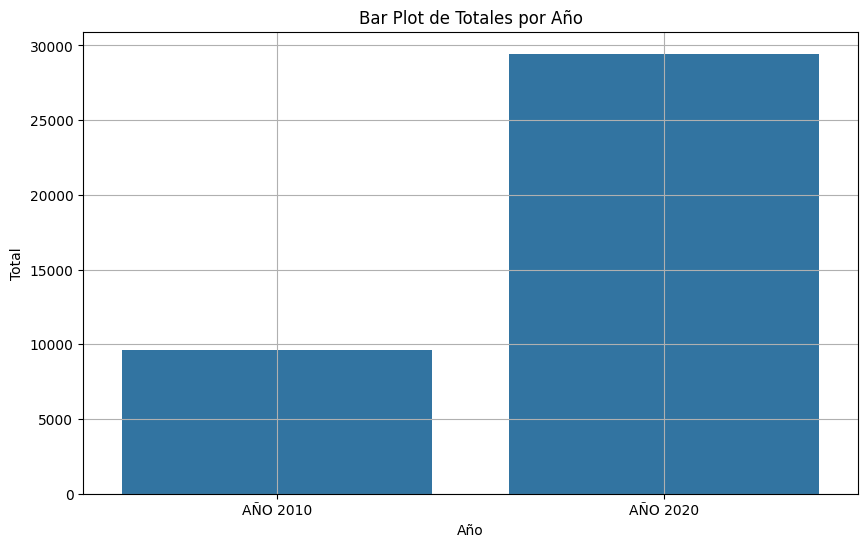

In [2]:
# 19. Now, let's create a Bar Plot to visualize the totals
plt.figure(figsize=(10, 6))
sns.barplot(x='Año', y='Total', data=total_df)
plt.title('Bar Plot de Totales por Año')
plt.xlabel('Año')
plt.ylabel('Total')
plt.grid()
plt.show()

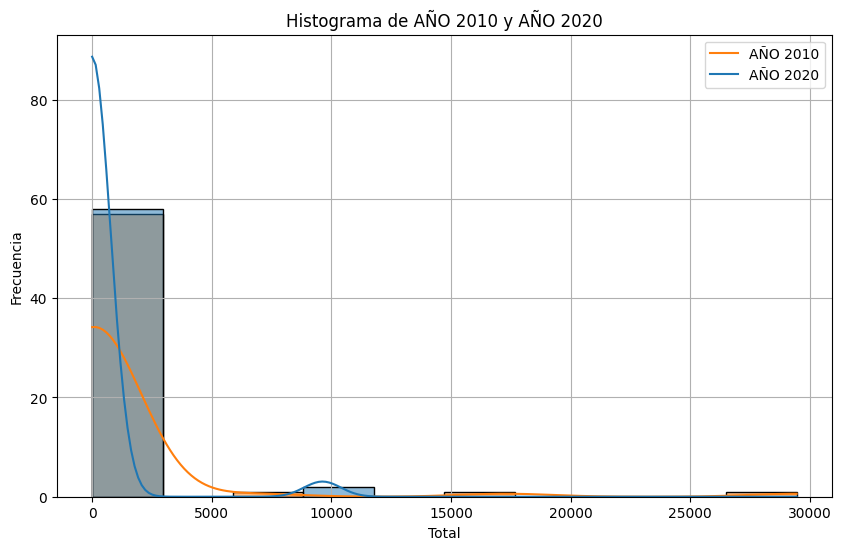

In [3]:
# 20. Next, we'll create a Histplot for individual years
plt.figure(figsize=(10, 6))
sns.histplot(data=filtered_df[['AÑO 2010', 'AÑO 2020']], bins=10, kde=True)
plt.title('Histograma de AÑO 2010 y AÑO 2020')
plt.xlabel('Total')
plt.ylabel('Frecuencia')
plt.legend(['AÑO 2010', 'AÑO 2020'])
plt.grid()
plt.show()

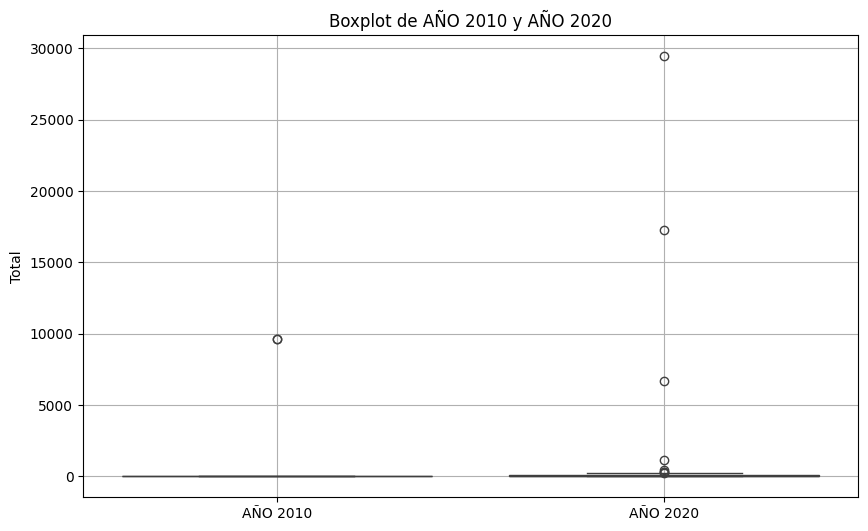

In [4]:
# 21. Let's compare both years with a Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=filtered_df[['AÑO 2010', 'AÑO 2020']])
plt.title('Boxplot de AÑO 2010 y AÑO 2020')
plt.ylabel('Total')
plt.xticks(ticks=[0, 1], labels=['AÑO 2010', 'AÑO 2020'])
plt.grid()
plt.show()

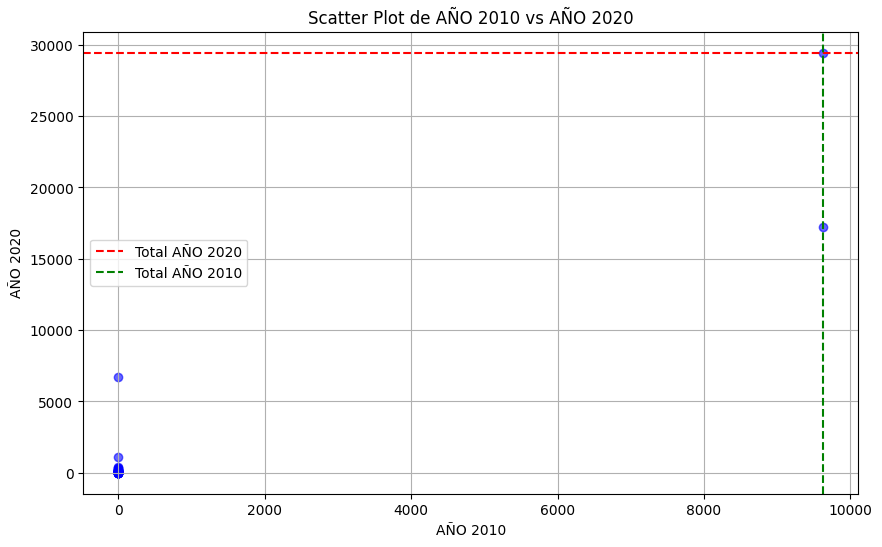

In [5]:
# 22. A Scatter Plot to visualize the relationship between both years
plt.figure(figsize=(10, 6))
plt.scatter(filtered_df['AÑO 2010'], filtered_df['AÑO 2020'], color='blue', alpha=0.6)
plt.title('Scatter Plot de AÑO 2010 vs AÑO 2020')
plt.xlabel('AÑO 2010')
plt.ylabel('AÑO 2020')
plt.grid()
plt.axhline(y=año_2020_total, color='r', linestyle='--', label='Total AÑO 2020')
plt.axvline(x=año_2010_total, color='g', linestyle='--', label='Total AÑO 2010')
plt.legend()
plt.show()